In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv("cleaned_energy_data.csv", low_memory=False)

# 'time' is Unix timestamp stored as string — convert to number first, then to datetime
df['time'] = pd.to_numeric(df['time'], errors='coerce')
df.dropna(subset=['time'], inplace=True)
df['timestamp'] = pd.to_datetime(df['time'], unit='s')
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)
df.drop(columns=['time'], inplace=True)

print("Dataset loaded successfully!")
print(f"Shape     : {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

Dataset loaded successfully!
Shape     : (503910, 31)
Date range: 2016-01-01 05:00:00 to 2016-01-07 00:58:29


,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 05:00:00,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:01,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,0.013117,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:02,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,0.013083,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:03,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,0.013000,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2016-01-01 05:00:04,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,0.012783,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [2]:
# Resample raw data to hourly averages
# Raw data is per-second — hourly reduces noise and speeds up model training
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_hourly = df[numeric_cols].resample('h').mean()
df_hourly.dropna(subset=['House overall [kW]'], inplace=True)

print(f"Resampled to hourly data")
print(f"Shape: {df_hourly.shape}")
df_hourly.head()

Resampled to hourly data
Shape: (140, 28)


,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 05:00:00,1.187276,0.038035,1.187276,0.055087,0.209051,0.236018,0.091815,0.066464,0.019766,0.013373,...,33.010339,0.609728,9.905267,26.325956,1013.323967,7.733644,250.486667,0.000035,20.923411,0.000644
2016-01-01 06:00:00,1.119695,0.080241,1.119695,0.044929,0.237062,0.251944,0.131420,0.052407,0.019162,0.013601,...,18.775006,0.584022,9.916806,9.766472,1024.161161,8.287394,293.827222,0.000000,6.187989,0.000000
2016-01-01 07:00:00,0.953479,0.074560,0.953479,0.036512,0.225252,0.204517,0.100471,0.066452,0.017028,0.013425,...,24.236133,0.614706,9.929494,20.451156,1027.502767,3.838150,131.142778,0.000000,11.636817,0.000000
2016-01-01 08:00:00,1.080323,0.013110,1.080323,0.030701,0.157488,0.187387,0.097202,0.057517,0.021887,0.014500,...,39.956900,0.784944,8.501144,36.097106,1012.871561,6.648811,116.138889,0.010007,33.599206,0.147417
2016-01-01 09:00:00,1.064834,0.046615,1.064834,0.042406,0.236579,0.272748,0.099082,0.057820,0.015738,0.013374,...,24.463689,0.562878,9.119567,15.937556,1010.960267,9.551461,241.294444,0.000385,10.398067,0.014661


In [3]:
df_hourly['hour']         = df_hourly.index.hour
df_hourly['day_of_week']  = df_hourly.index.dayofweek
df_hourly['day_of_month'] = df_hourly.index.day
df_hourly['month']        = df_hourly.index.month
df_hourly['quarter']      = df_hourly.index.quarter
df_hourly['week_of_year'] = df_hourly.index.isocalendar().week.astype(int)
df_hourly['is_weekend']   = (df_hourly['day_of_week'] >= 5).astype(int)
df_hourly['is_peak_hour'] = df_hourly['hour'].apply(
    lambda h: 1 if (7 <= h <= 9) or (18 <= h <= 21) else 0
)

# Cyclical encoding of hour and month
df_hourly['hour_sin']  = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos']  = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['month_sin'] = np.sin(2 * np.pi * df_hourly['month'] / 12)
df_hourly['month_cos'] = np.cos(2 * np.pi * df_hourly['month'] / 12)

# Part of day: 0=morning, 1=afternoon, 2=evening, 3=night
df_hourly['part_of_day'] = df_hourly['hour'].apply(
    lambda h: 0 if 5 <= h < 12 else (1 if 12 <= h < 17 else (2 if 17 <= h < 21 else 3))
)

print("Time-based features created!")
print(df_hourly[['hour','day_of_week','month','is_weekend','is_peak_hour','part_of_day']].head(5))

Time-based features created!
                     hour  day_of_week  month  is_weekend  is_peak_hour  \
timestamp                                                                 
2016-01-01 05:00:00     5            4      1           0             0   
2016-01-01 06:00:00     6            4      1           0             0   
2016-01-01 07:00:00     7            4      1           0             1   
2016-01-01 08:00:00     8            4      1           0             1   
2016-01-01 09:00:00     9            4      1           0             1   

                     part_of_day  
timestamp                         
2016-01-01 05:00:00            0  
2016-01-01 06:00:00            0  
2016-01-01 07:00:00            0  
2016-01-01 08:00:00            0  
2016-01-01 09:00:00            0  


In [4]:
device_cols = [
    'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]',
    'Home office [kW]', 'Fridge [kW]', 'Wine cellar [kW]',
    'Garage door [kW]', 'Kitchen 12 [kW]', 'Kitchen 14 [kW]',
    'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
    'Microwave [kW]', 'Living room [kW]'
]
available_devices = [c for c in device_cols if c in df_hourly.columns]

df_hourly['total_device_kW'] = df_hourly[available_devices].sum(axis=1)
df_hourly['max_device_kW']   = df_hourly[available_devices].max(axis=1)
df_hourly['mean_device_kW']  = df_hourly[available_devices].mean(axis=1)
df_hourly['active_devices']  = (df_hourly[available_devices] > 0.01).sum(axis=1)

print("Device aggregation features created!")
print(df_hourly[['total_device_kW','max_device_kW','mean_device_kW','active_devices']].describe())

Device aggregation features created!
       total_device_kW  max_device_kW  mean_device_kW  active_devices
count       140.000000     140.000000      140.000000      140.000000
mean          0.598750       0.148135        0.042768       10.378571
std           0.159165       0.065798        0.011369        1.048931
min           0.282256       0.066122        0.020161        7.000000
25%           0.482496       0.095920        0.034464       10.000000
50%           0.580458       0.126542        0.041461       10.000000
75%           0.706279       0.189909        0.050449       11.000000
max           1.081585       0.396536        0.077256       13.000000


In [5]:
target = 'House overall [kW]'

df_hourly['lag_1']   = df_hourly[target].shift(1)
df_hourly['lag_2']   = df_hourly[target].shift(2)
df_hourly['lag_3']   = df_hourly[target].shift(3)
df_hourly['lag_6']   = df_hourly[target].shift(6)
df_hourly['lag_12']  = df_hourly[target].shift(12)
df_hourly['lag_24']  = df_hourly[target].shift(24)
df_hourly['lag_168'] = df_hourly[target].shift(168)

print("Lag features created!")
print(df_hourly[['lag_1','lag_24','lag_168']].dropna().head(5))

Lag features created!
Empty DataFrame
Columns: [lag_1, lag_24, lag_168]
Index: []


In [6]:
df_hourly['rolling_mean_3']  = df_hourly[target].shift(1).rolling(3).mean()
df_hourly['rolling_mean_6']  = df_hourly[target].shift(1).rolling(6).mean()
df_hourly['rolling_mean_24'] = df_hourly[target].shift(1).rolling(24).mean()
df_hourly['rolling_mean_7d'] = df_hourly[target].shift(1).rolling(168).mean()
df_hourly['rolling_std_24']  = df_hourly[target].shift(1).rolling(24).std()
df_hourly['rolling_max_24']  = df_hourly[target].shift(1).rolling(24).max()
df_hourly['rolling_min_24']  = df_hourly[target].shift(1).rolling(24).min()

print("Rolling window features created!")
print(df_hourly[['rolling_mean_3','rolling_mean_24','rolling_std_24']].dropna().head(5))

Rolling window features created!
                     rolling_mean_3  rolling_mean_24  rolling_std_24
timestamp                                                           
2016-01-02 05:00:00        0.948044         1.019715        0.146684
2016-01-02 06:00:00        0.847237         1.002294        0.150691
2016-01-02 07:00:00        0.831781         0.989074        0.153828
2016-01-02 08:00:00        0.796532         0.983429        0.157630
2016-01-02 09:00:00        0.720125         0.960914        0.180168


In [7]:
weather_cols = ['temperature','humidity','windSpeed',
                'apparentTemperature','precipIntensity','cloudCover']
available_weather = []
for col in weather_cols:
    if col in df_hourly.columns:
        df_hourly[col] = pd.to_numeric(df_hourly[col], errors='coerce')
        available_weather.append(col)

print(f"Weather features included: {available_weather}")

Weather features included: ['temperature', 'humidity', 'windSpeed', 'apparentTemperature', 'precipIntensity']


In [8]:
time_features    = ['hour','day_of_week','day_of_month','month','quarter','week_of_year',
                    'is_weekend','is_peak_hour','hour_sin','hour_cos','month_sin','month_cos','part_of_day']
device_features  = ['total_device_kW','max_device_kW','mean_device_kW','active_devices']
lag_features     = ['lag_1','lag_2','lag_3','lag_6','lag_12','lag_24','lag_168']
rolling_features = ['rolling_mean_3','rolling_mean_6','rolling_mean_24',
                    'rolling_mean_7d','rolling_std_24','rolling_max_24','rolling_min_24']

all_features = time_features + device_features + lag_features + rolling_features + available_weather

df_final = df_hourly[all_features + [target]].dropna().copy()

print("Final feature matrix ready!")
print(f"Shape          : {df_final.shape}")
print(f"Total features : {len(all_features)}")
print(f"Samples        : {len(df_final):,}")
print(f"Date range     : {df_final.index.min()} to {df_final.index.max()}")
print(f"\nFeature breakdown:")
print(f"  Time features    : {len(time_features)}")
print(f"  Device features  : {len(device_features)}")
print(f"  Lag features     : {len(lag_features)}")
print(f"  Rolling features : {len(rolling_features)}")
print(f"  Weather features : {len(available_weather)}")
df_final.head()

Final feature matrix ready!
Shape          : (0, 37)
Total features : 36
Samples        : 0
Date range     : NaT to NaT

Feature breakdown:
  Time features    : 13
  Device features  : 4
  Lag features     : 7
  Rolling features : 7
  Weather features : 5


,hour,day_of_week,day_of_month,month,quarter,week_of_year,is_weekend,is_peak_hour,hour_sin,hour_cos,...,rolling_mean_7d,rolling_std_24,rolling_max_24,rolling_min_24,temperature,humidity,windSpeed,apparentTemperature,precipIntensity,House overall [kW]
timestamp,,,,,,,,,,,,,,,,,,,,,


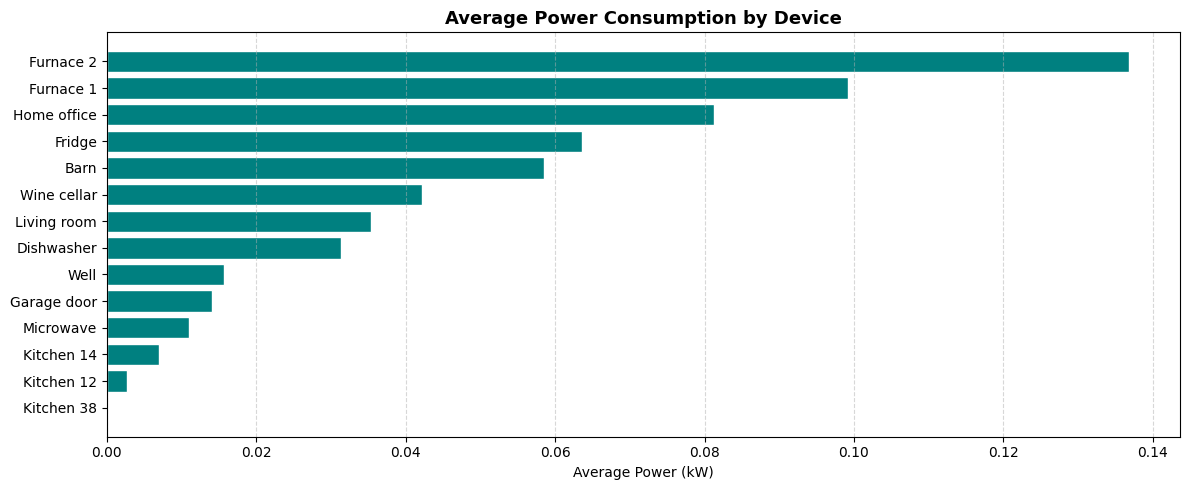

In [11]:
device_avg = df_hourly[available_devices].mean().sort_values(ascending=False)
clean_labels = [c.replace(' [kW]', '') for c in device_avg.index]

plt.figure(figsize=(12, 5))
plt.barh(clean_labels, device_avg.values, color='teal', edgecolor='white')
plt.title("Average Power Consumption by Device", fontsize=13, fontweight='bold')
plt.xlabel("Average Power (kW)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
print("Before processing:", df['House overall [kW]'].count())
print("After processing:", df_final['House overall [kW]'].count())

Before processing: 503910
After processing: 0


In [21]:
df.columns

Index(['use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]',
       'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]',
       'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]',
       'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
       'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature',
       'icon', 'humidity', 'visibility', 'summary', 'apparentTemperature',
       'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity',
       'dewPoint', 'precipProbability'],
      dtype='str')

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target = 'House overall [kW]'

# Fix index
df.index = pd.to_datetime(df.index, errors='coerce')
df = df.sort_index()
df = df[~df.index.duplicated()]

# Keep only numeric columns before resampling
df_numeric = df.select_dtypes(include=[np.number])

# Resampling
df_hourly  = df_numeric.resample('h').mean()
df_daily   = df_numeric.resample('d').mean()
df_weekly  = df_numeric.resample('w').mean()
df_monthly = df_numeric.resample('ME').mean()

print("Hourly shape:", df_hourly.shape)
print("Daily shape:", df_daily.shape)
print("Weekly shape:", df_weekly.shape)
print("Monthly shape:", df_monthly.shape)

Hourly shape: (1, 32)
Daily shape: (1, 32)
Weekly shape: (1, 32)
Monthly shape: (1, 32)


In [14]:
df_final.to_csv('feature_engineered_data.csv')

print("Feature engineering complete!")
print(f"  Saved          : feature_engineered_data.csv")
print(f"  Total samples  : {len(df_final):,}")
print(f"  Total features : {len(all_features)}")
print(f"  Target column  : {target}")
print()
print("Ready for Module 4: Baseline Model (Linear Regression)!")

Feature engineering complete!
  Saved          : feature_engineered_data.csv
  Total samples  : 0
  Total features : 36
  Target column  : House overall [kW]

Ready for Module 4: Baseline Model (Linear Regression)!


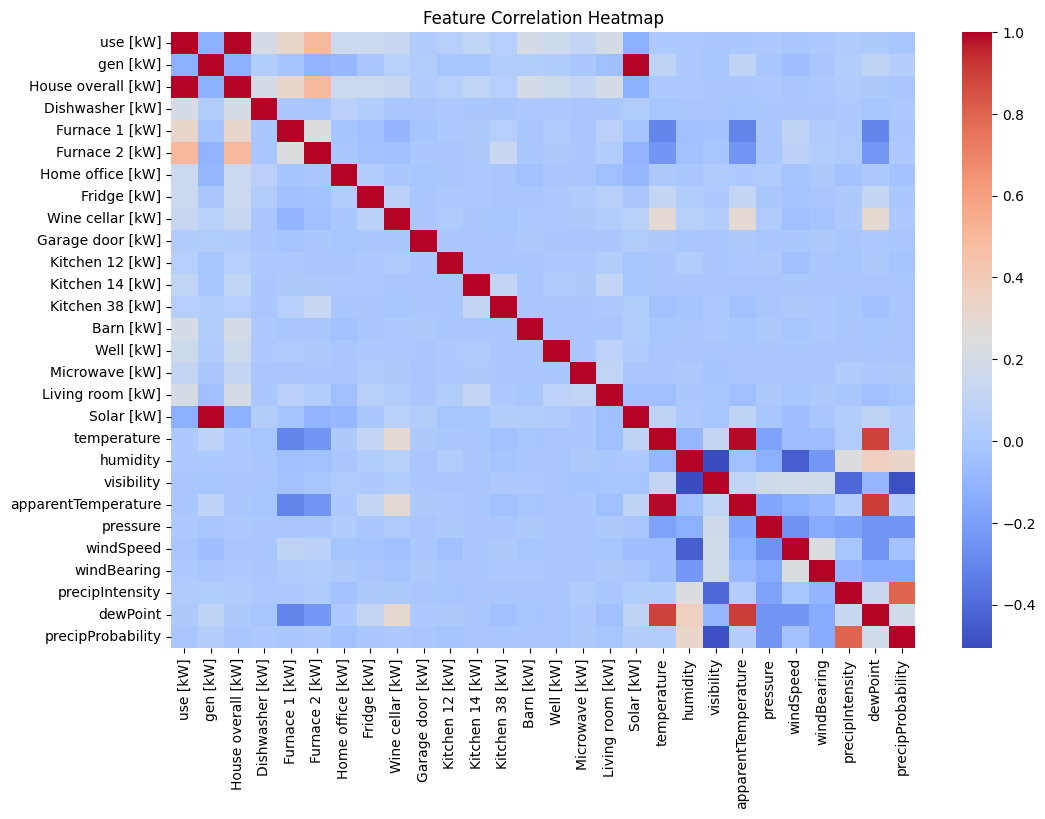

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [60]:
# Make sure index is datetime
df.index = pd.to_datetime(df.index, errors='coerce')

# Create time features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

target = 'House overall [kW]'

# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Features and target
X = df_numeric[['time_index']]   # time variable
y = df_numeric[target]

print("Total samples:", len(X))

# Train-test split (time series → shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

Total samples: 491521


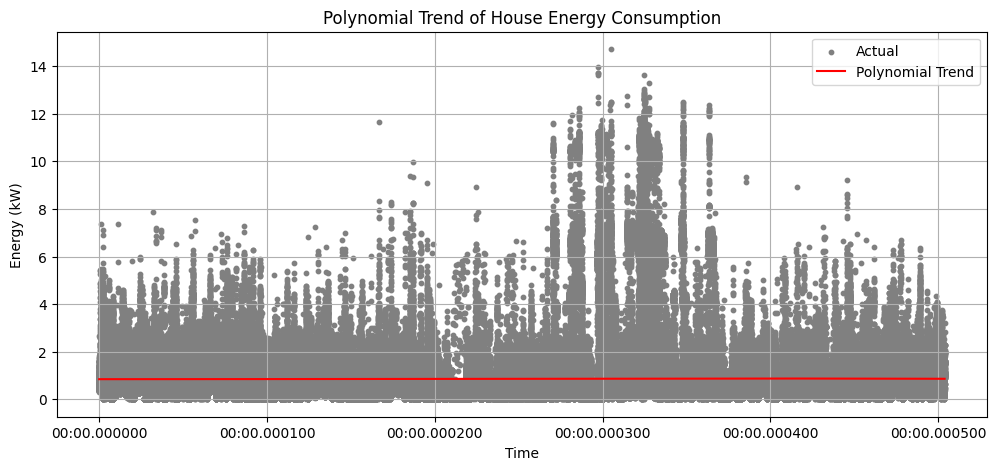

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

target = 'House overall [kW]'

# Make sure datetime index
df.index = pd.to_datetime(df.index, errors='coerce')

# Keep only needed columns
poly_df = df[[target]].copy()

# Remove NaN values (VERY IMPORTANT)
poly_df = poly_df.dropna()

# Create time index
poly_df['time_index'] = np.arange(len(poly_df))

# X and y
X = poly_df[['time_index']]
y = poly_df[target]

# Polynomial model
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

# Plot
plt.figure(figsize=(12,5))
plt.scatter(poly_df.index, y, s=10, color='gray', label='Actual')
plt.plot(poly_df.index, y_pred, color='red', label='Polynomial Trend')

plt.title("Polynomial Trend of House Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy (kW)")
plt.legend()
plt.grid(True)
plt.show()

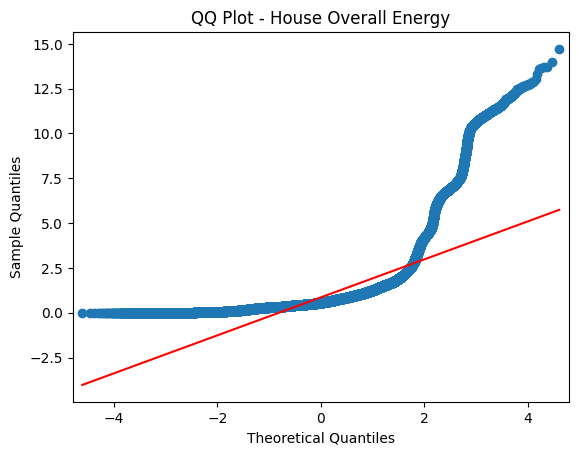

In [47]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

target = 'House overall [kW]'

# Remove NaN values
qq_data = df[target].dropna()

# QQ Plot
sm.qqplot(qq_data, line='s')
plt.title("QQ Plot - House Overall Energy")
plt.show()

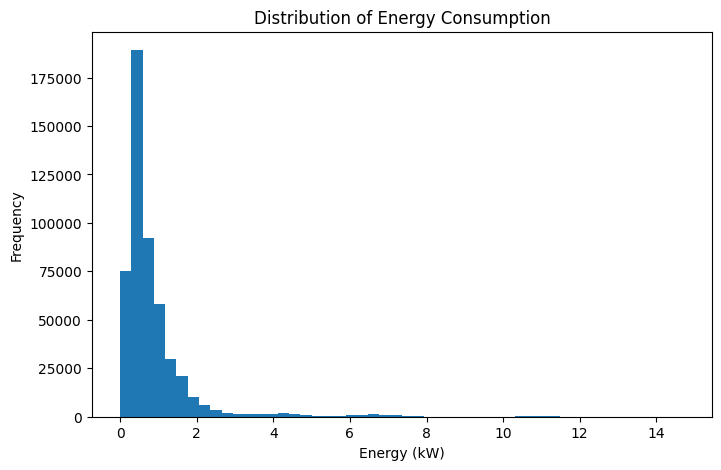

In [48]:
plt.figure(figsize=(8,5))
plt.hist(df[target].dropna(), bins=50)
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy (kW)")
plt.ylabel("Frequency")
plt.show()

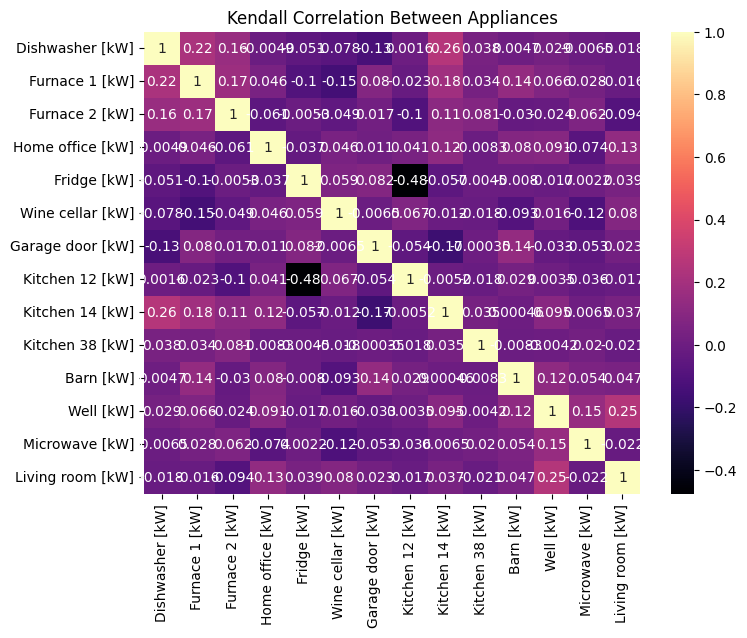

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

device_cols = [
    'Dishwasher [kW]',
    'Furnace 1 [kW]',
    'Furnace 2 [kW]',
    'Home office [kW]',
    'Fridge [kW]',
    'Wine cellar [kW]',
    'Garage door [kW]',
    'Kitchen 12 [kW]',
    'Kitchen 14 [kW]',
    'Kitchen 38 [kW]',
    'Barn [kW]',
    'Well [kW]',
    'Microwave [kW]',
    'Living room [kW]'
]

# Remove NaN
device_df = df[device_cols].dropna()

# Kendall correlation
kendall_corr = device_df.corr(method='kendall')

plt.figure(figsize=(8,6))
sns.heatmap(kendall_corr, annot=True, cmap='magma')
plt.title("Kendall Correlation Between Appliances")
plt.show()